**Data Collection**

In [ ]:
import pandas as pd

file_path = "/content/BikeWale_Vehicle_Dataset.csv"

try:
    df = pd.read_csv(file_path)
    print("CSV file loaded successfully!")
    print("First 5 rows of the DataFrame:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
First 5 rows of the DataFrame:
   vehicle_id   brand        model      vehicle_type fuel_type  \
0           1  Suzuki   V-Strom SX              Bike    Petrol   
1           2   Honda   Hornet 2.0           Scooter    Petrol   
2           3   Bajaj  Dominar 400              Bike    Petrol   
3           4   Ather         450X  Electric Scooter  Electric   
4           5  Yamaha        MT-15           Scooter    Petrol   

   ex_showroom_price  on_road_price  mileage_kmpl_or_range_km  engine_cc  \
0             430838         481987                      69.3        160   
1             317709         372799                      40.0        160   
2             393947         465502                      63.7        125   
3             209243         242601                     116.5          1   
4             236829         287212                      41.3        110   

   power_bhp transmission  number_of_variants  number_of_colors       city  \
0      

**Data Cleaning**

In [ ]:
import pandas as pd

df = pd.read_csv("BikeWale_Vehicle_Dataset.csv")

print(df.shape)
print(df.head())

(500, 17)
   vehicle_id   brand        model      vehicle_type fuel_type  \
0           1  Suzuki   V-Strom SX              Bike    Petrol   
1           2   Honda   Hornet 2.0           Scooter    Petrol   
2           3   Bajaj  Dominar 400              Bike    Petrol   
3           4   Ather         450X  Electric Scooter  Electric   
4           5  Yamaha        MT-15           Scooter    Petrol   

   ex_showroom_price  on_road_price  mileage_kmpl_or_range_km  engine_cc  \
0             430838         481987                      69.3        160   
1             317709         372799                      40.0        160   
2             393947         465502                      63.7        125   
3             209243         242601                     116.5          1   
4             236829         287212                      41.3        110   

   power_bhp transmission  number_of_variants  number_of_colors       city  \
0       12.9       Manual                   3             

In [ ]:
print(df.isnull().sum())

vehicle_id                  0
brand                       0
model                       0
vehicle_type                0
fuel_type                   0
ex_showroom_price           0
on_road_price               0
mileage_kmpl_or_range_km    0
engine_cc                   0
power_bhp                   5
transmission                0
number_of_variants          0
number_of_colors            5
city                        0
rating                      5
review_count                0
model_year                  0
dtype: int64


In [ ]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [ ]:
df["rating"] = df["rating"].fillna(df["rating"].median())

df["number_of_colors"] = df["number_of_colors"].fillna(
    df["number_of_colors"].median()
)

df["power_bhp"] = df["power_bhp"].fillna(
    df["power_bhp"].median()
)

In [ ]:
print(df.dtypes)

vehicle_id                    int64
brand                        object
model                        object
vehicle_type                 object
fuel_type                    object
ex_showroom_price             int64
on_road_price                 int64
mileage_kmpl_or_range_km    float64
engine_cc                     int64
power_bhp                   float64
transmission                 object
number_of_variants            int64
number_of_colors            float64
city                         object
rating                      float64
review_count                  int64
model_year                    int64
dtype: object


In [ ]:
print(df[df["ex_showroom_price"] <= 0])
print(df[df["on_road_price"] <= 0])
print(df[df["rating"] < 0])
print(df[df["rating"] > 5])

Empty DataFrame
Columns: [vehicle_id, brand, model, vehicle_type, fuel_type, ex_showroom_price, on_road_price, mileage_kmpl_or_range_km, engine_cc, power_bhp, transmission, number_of_variants, number_of_colors, city, rating, review_count, model_year]
Index: []
Empty DataFrame
Columns: [vehicle_id, brand, model, vehicle_type, fuel_type, ex_showroom_price, on_road_price, mileage_kmpl_or_range_km, engine_cc, power_bhp, transmission, number_of_variants, number_of_colors, city, rating, review_count, model_year]
Index: []
Empty DataFrame
Columns: [vehicle_id, brand, model, vehicle_type, fuel_type, ex_showroom_price, on_road_price, mileage_kmpl_or_range_km, engine_cc, power_bhp, transmission, number_of_variants, number_of_colors, city, rating, review_count, model_year]
Index: []
Empty DataFrame
Columns: [vehicle_id, brand, model, vehicle_type, fuel_type, ex_showroom_price, on_road_price, mileage_kmpl_or_range_km, engine_cc, power_bhp, transmission, number_of_variants, number_of_colors, city, 

In [ ]:
df.to_csv("BikeWale_Cleaned_Data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


**Exploratory Data Analysis**

In [ ]:
#Basic Statistics
print(df.describe())

       vehicle_id  ex_showroom_price  on_road_price  mileage_kmpl_or_range_km  \
count  500.000000         500.000000     500.000000                500.000000   
mean   250.500000      243058.832000  282118.568000                 75.212400   
std    144.481833      114014.377408  132889.715555                 37.575379   
min      1.000000       65363.000000   77594.000000                 40.000000   
25%    125.750000      147318.000000  168008.250000                 52.800000   
50%    250.500000      215893.500000  251875.000000                 63.500000   
75%    375.250000      352308.500000  408603.750000                 75.800000   
max    500.000000      447650.000000  540831.000000                199.500000   

        engine_cc   power_bhp  number_of_variants  number_of_colors  \
count  500.000000  500.000000          500.000000        500.000000   
mean   189.152000   22.952000            3.992000          3.048000   
std    137.798293   11.362866            0.805751        

In [ ]:
#Brand Analysis
brand_count = df["brand"].value_counts()

print(brand_count)

brand
Suzuki           67
Hero             63
Royal Enfield    54
Honda            53
Yamaha           52
KTM              51
Ather            50
Bajaj            42
Ola              37
TVS              31
Name: count, dtype: int64


In [ ]:
#Fuel Type Analysis
print(df["fuel_type"].value_counts())

fuel_type
Petrol      413
Electric     87
Name: count, dtype: int64


In [ ]:
#Vehicle Type Analysis
print(df["vehicle_type"].value_counts())

vehicle_type
Scooter             223
Bike                208
Electric Scooter     69
Name: count, dtype: int64


In [ ]:
#Average Price by Brand
brand_price = df.groupby("brand")["ex_showroom_price"].mean()

print(brand_price.sort_values(ascending=False))

brand
Honda            277520.377358
Bajaj            270291.809524
Suzuki           268179.343284
Yamaha           265616.288462
Royal Enfield    263632.074074
Hero             261579.571429
TVS              246401.096774
KTM              235210.078431
Ola              158862.108108
Ather            149216.520000
Name: ex_showroom_price, dtype: float64


In [ ]:
#Average Rating by Brand
brand_rating = df.groupby("brand")["rating"].mean()

print(brand_rating.sort_values(ascending=False))

brand
KTM              4.276471
TVS              4.232258
Bajaj            4.169048
Honda            4.132075
Suzuki           4.125373
Yamaha           4.101923
Hero             4.077778
Ola              4.024324
Royal Enfield    4.011111
Ather            3.910000
Name: rating, dtype: float64


In [ ]:
#Price vs Rating
print(
    df[["ex_showroom_price", "rating"]].corr())

                   ex_showroom_price    rating
ex_showroom_price           1.000000  0.010911
rating                      0.010911  1.000000


In [ ]:
#Mileage Analysis
print(df["mileage_kmpl_or_range_km"].describe())

count    500.000000
mean      75.212400
std       37.575379
min       40.000000
25%       52.800000
50%       63.500000
75%       75.800000
max      199.500000
Name: mileage_kmpl_or_range_km, dtype: float64


In [ ]:
#Engine Capacity Analysis
print(df["engine_cc"].describe())

count    500.000000
mean     189.152000
std      137.798293
min        0.000000
25%      100.000000
50%      150.000000
75%      300.000000
max      450.000000
Name: engine_cc, dtype: float64


**Data Visualization**

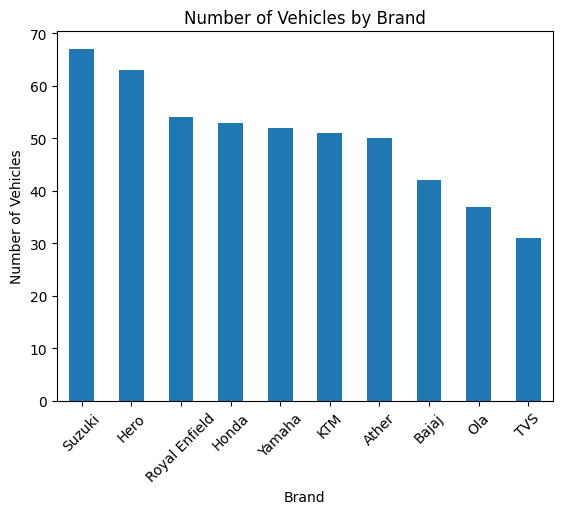

In [ ]:
#Brand Distribution
import matplotlib.pyplot as plt

df["brand"].value_counts().plot(kind="bar")

plt.title("Number of Vehicles by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

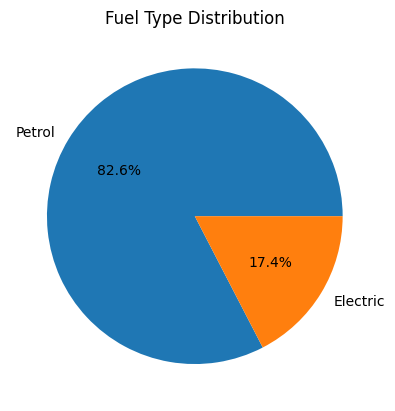

In [ ]:
#Fuel Type Pie Chart
df["fuel_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()

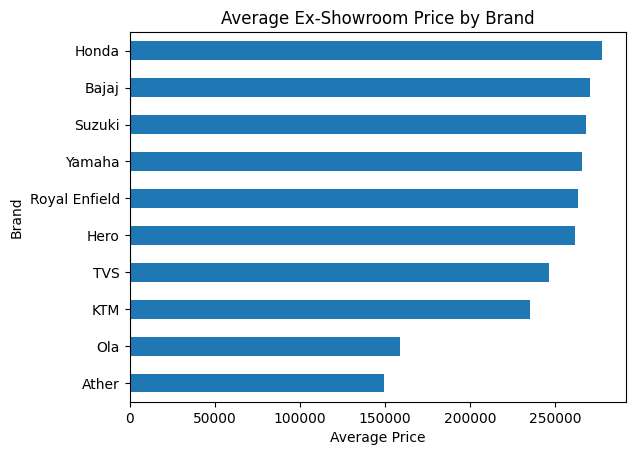

In [ ]:
#Average Price by Brand
df.groupby("brand")["ex_showroom_price"].mean().sort_values().plot(
    kind="barh"
)

plt.title("Average Ex-Showroom Price by Brand")
plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.show()

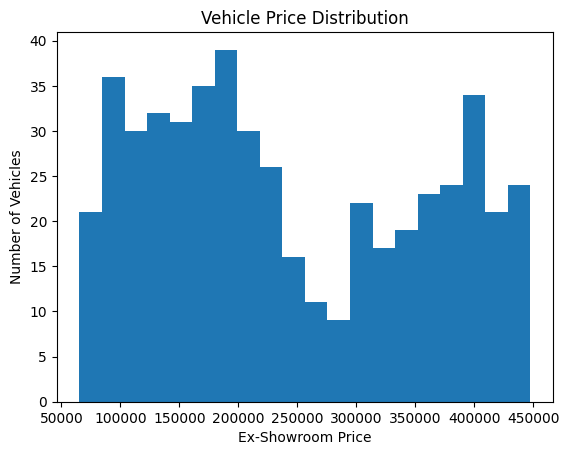

In [ ]:
#Price Distribution
plt.hist(df["ex_showroom_price"], bins=20)

plt.title("Vehicle Price Distribution")
plt.xlabel("Ex-Showroom Price")
plt.ylabel("Number of Vehicles")
plt.show()

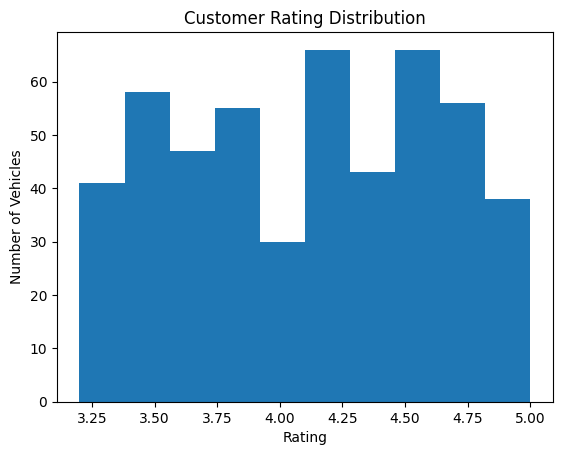

In [ ]:
#Rating Distribution
plt.hist(df["rating"].dropna(), bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Vehicles")
plt.show()

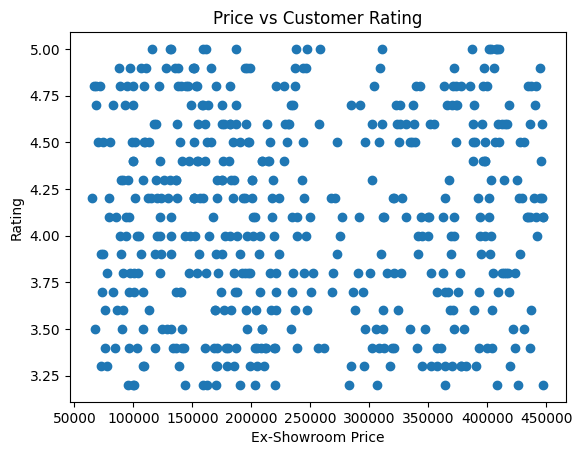

In [ ]:
#Price vs Rating
plt.scatter(
    df["ex_showroom_price"],
    df["rating"]
)

plt.title("Price vs Customer Rating")
plt.xlabel("Ex-Showroom Price")
plt.ylabel("Rating")
plt.show()